MEASURES OF CENTRAL TENDENCY AND DISPERSION
Teaching Module with Large Datasets

📊 DATASET 1: STUDENT EXAM SCORES ANALYSIS
--------------------------------------------------
Dataset contains 500 students across 5 subjects

First 10 rows:
   Math  Science  English  History   Art  Student_ID  Overall_Average
0  81.0     87.3     93.2     88.7  80.9           1             86.2
1  73.3     97.1     89.4     68.7  84.1           2             82.5
2  82.8     64.0     82.5     64.7  80.2           3             74.8
3  93.3     83.6     76.8     76.9  83.2           4             82.8
4  72.2     71.5     87.6     74.4  73.6           5             75.9
5  72.2     73.1     85.1     70.2  86.3           6             77.4
6  94.0     72.1     89.2     87.4  85.0           7             85.5
7  84.2     69.4     87.1     91.3  80.1           8             82.4
8  69.4     78.5     90.4     78.3  89.0           9             81.1
9  81.5     69.7     77.7     99.2  90.6          10          

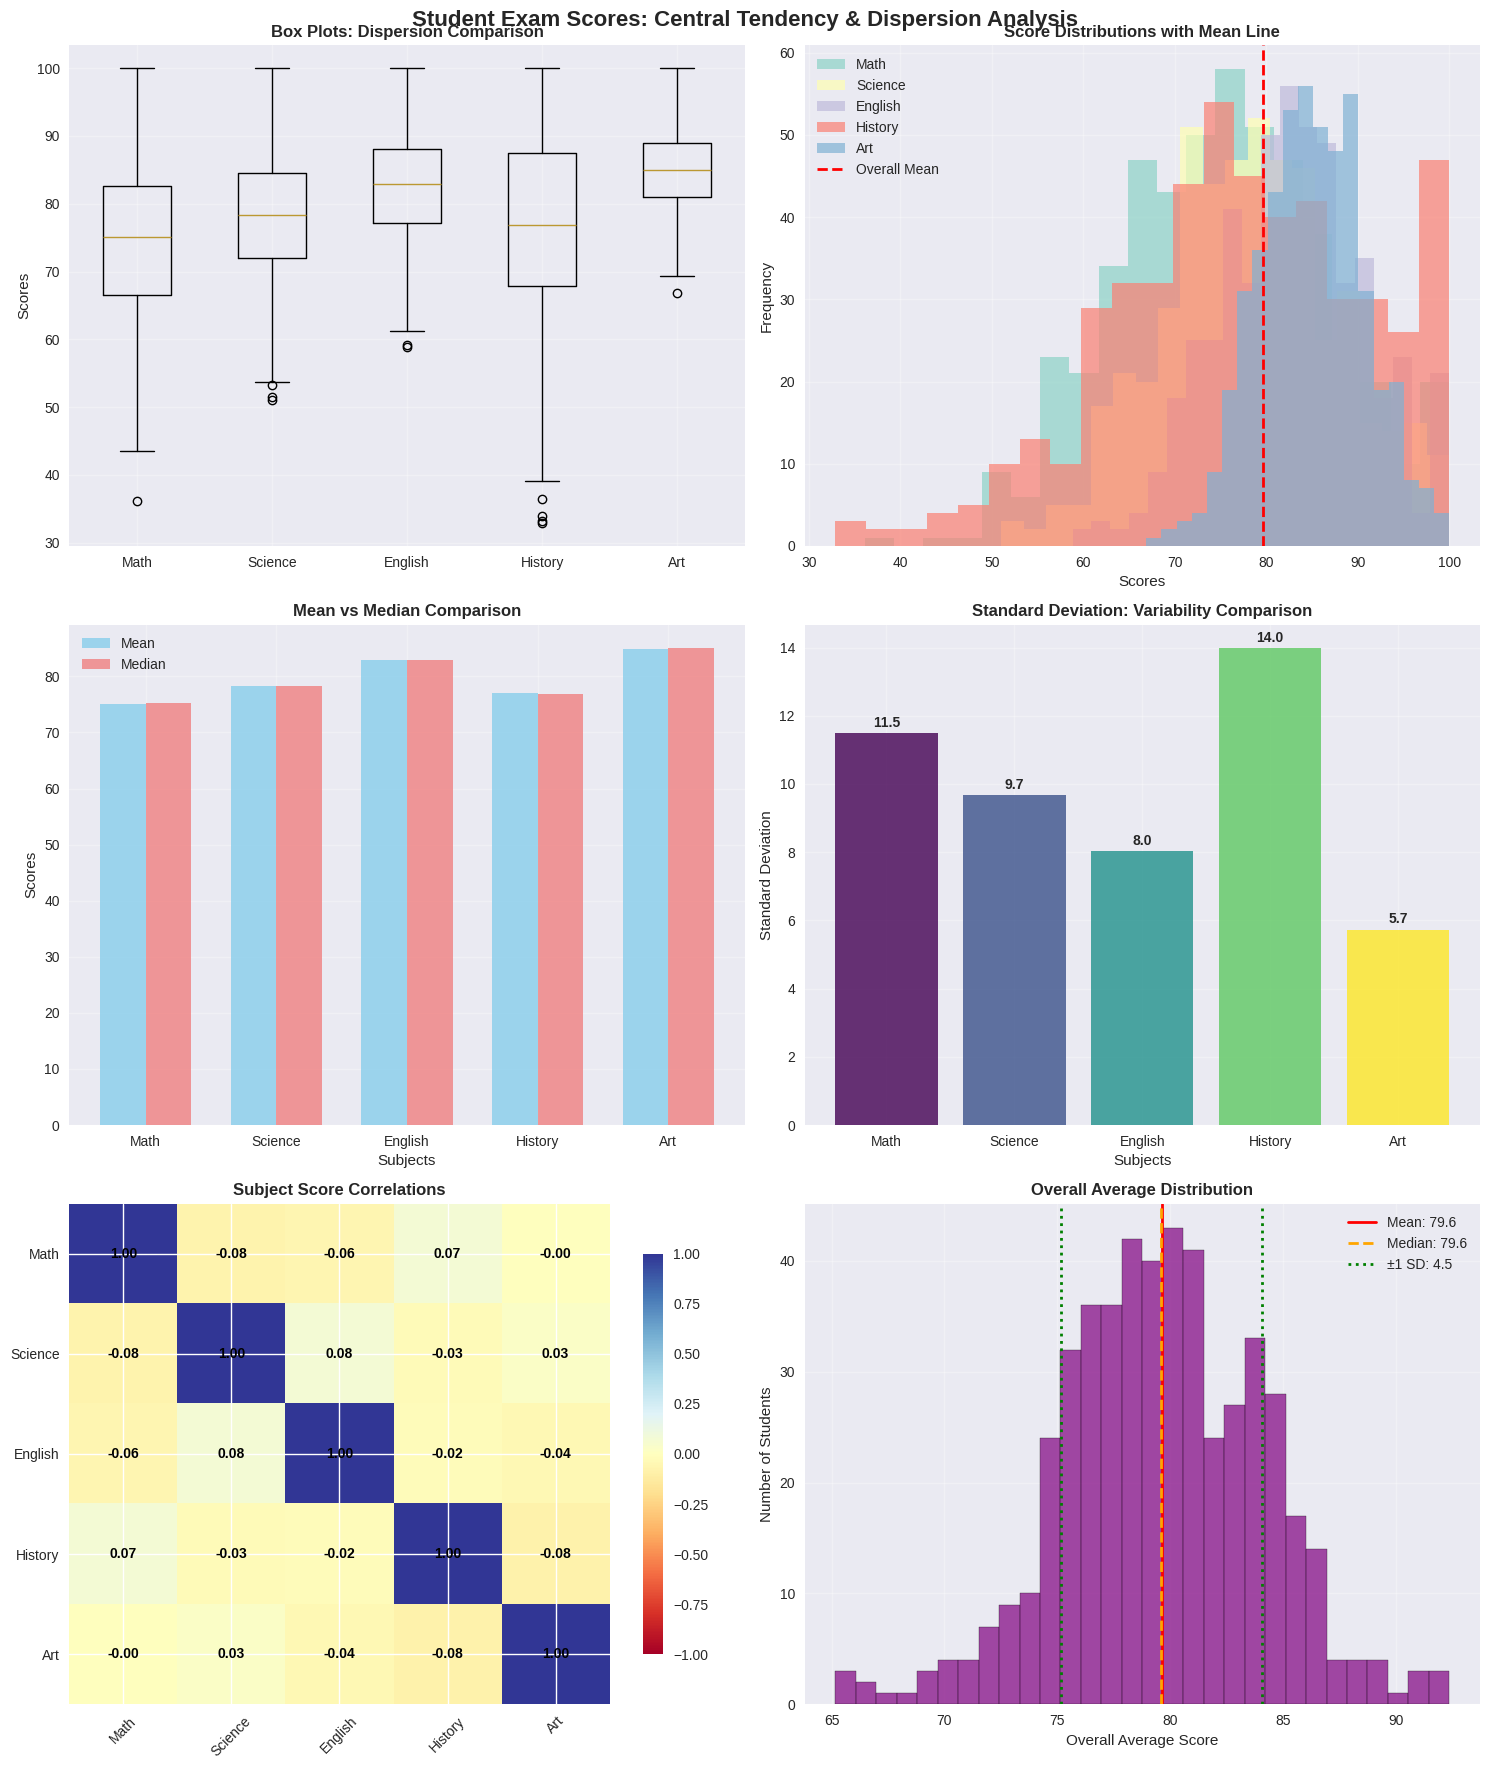



 DATASET 2: EMPLOYEE SALARY ANALYSIS
--------------------------------------------------
Dataset contains 1000 employees across 6 departments

Sample data:
   Employee_ID   Department         Salary  Experience_Years
0            1           HR   40578.633907          1.427215
1            2  Engineering  106125.857978          6.108143
2            3  Engineering  102820.228651          4.465095
3            4        Sales   71443.487494          4.357508
4            5           HR   73982.870704          5.245542
5            6    Marketing   64711.595482          3.105669
6            7   Operations   60910.416680          2.010099
7            8           HR   73180.914794          4.227417
8            9        Sales   99176.527639          1.056118
9           10    Marketing   73460.889401         10.791896

 SALARY ANALYSIS BY DEPARTMENT
---------------------------------------------
             Count      Mean    Median  Std Dev      Min       Max
Department                 

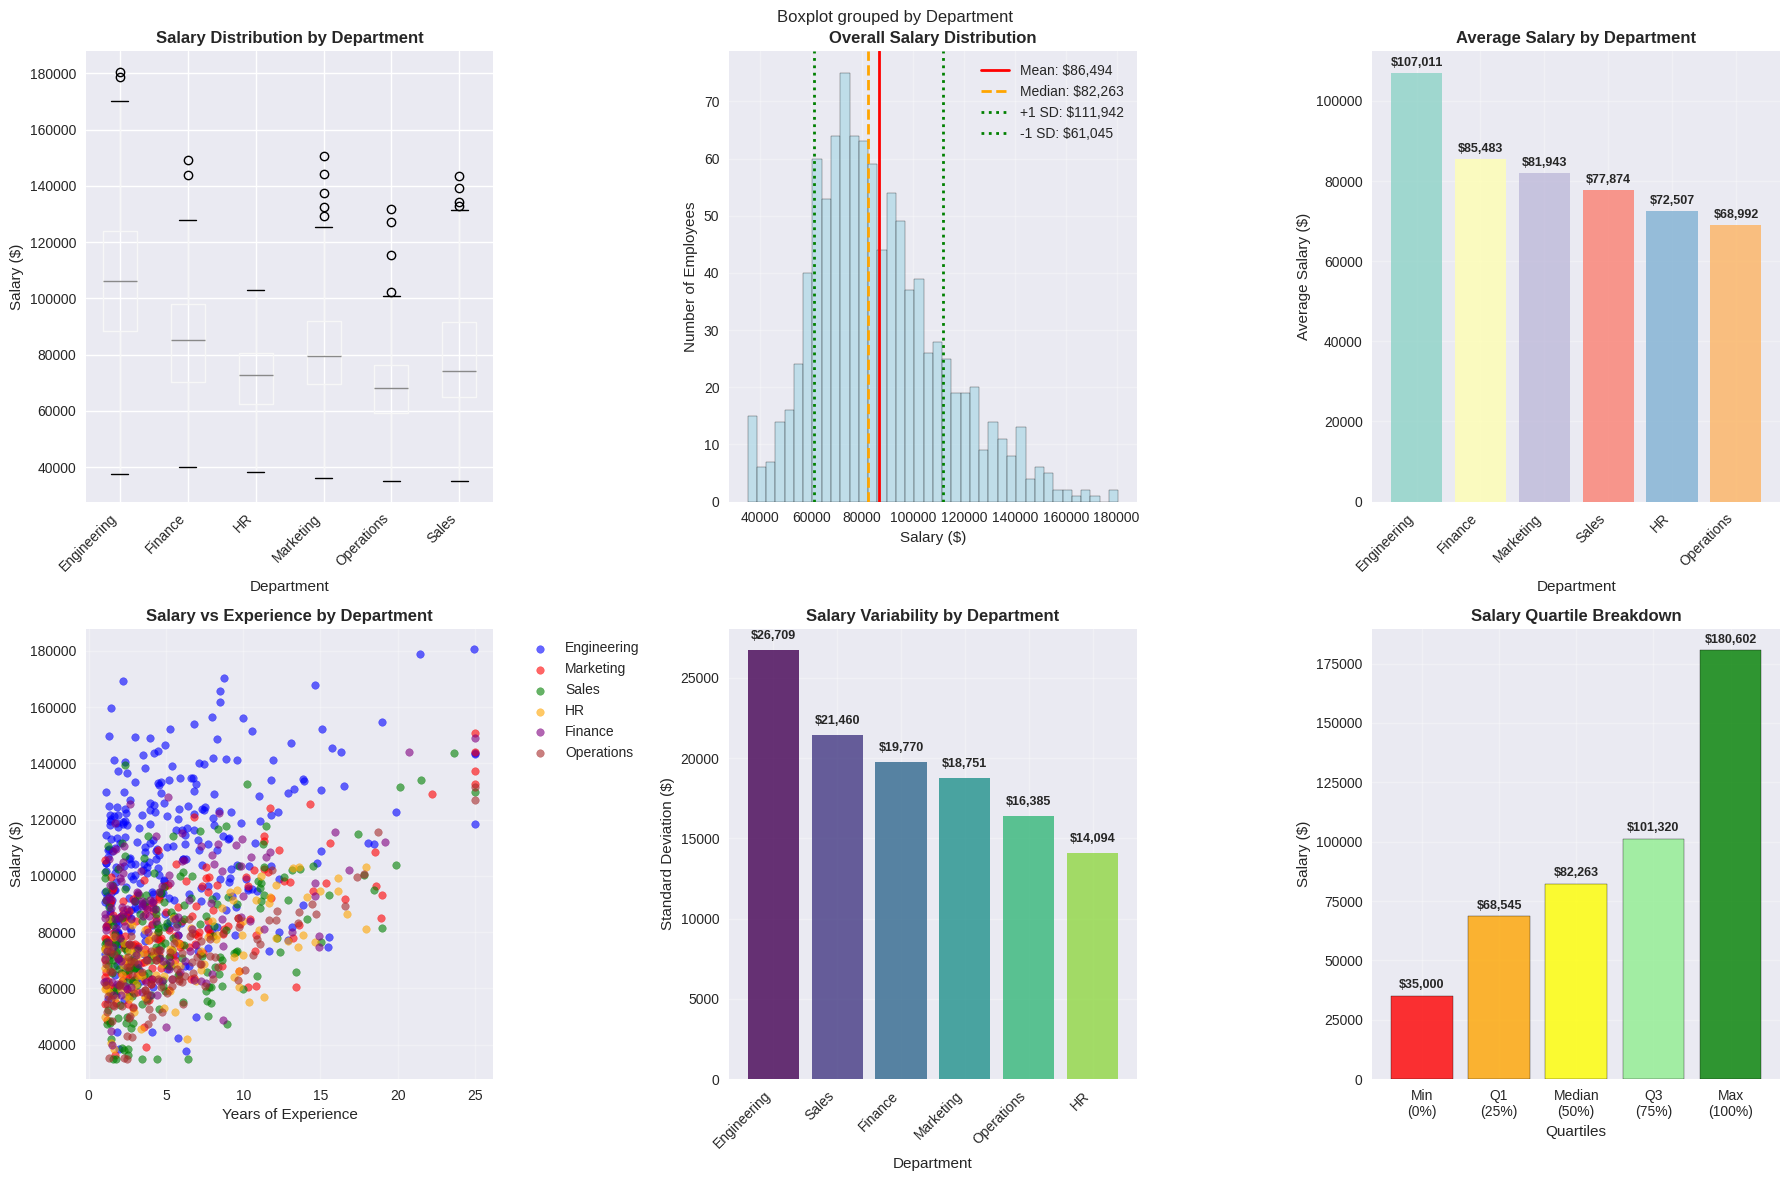



 TEACHING SUMMARY: KEY CONCEPTS

 MEASURES OF CENTRAL TENDENCY:
   • MEAN: Average value, sensitive to outliers
   • MEDIAN: Middle value, robust to outliers  
   • MODE: Most frequent value, useful for categorical data

 MEASURES OF DISPERSION:
   • STANDARD DEVIATION: Average distance from mean
   • VARIANCE: Squared standard deviation
   • RANGE: Difference between max and min
   • INTERQUARTILE RANGE (IQR): Q3 - Q1, robust measure
   
 INTERPRETATION GUIDELINES:
   • Higher standard deviation = more variability
   • Mean ≈ Median → symmetric distribution
   • Mean > Median → right-skewed distribution  
   • Mean < Median → left-skewed distribution
   
 VISUALIZATION BEST PRACTICES:
   • Box plots: Show quartiles and outliers
   • Histograms: Show distribution shape
   • Scatter plots: Show relationships between variables
   • Bar charts: Compare groups or categories


 NUMERICAL EXAMPLES FOR TEACHING:
   Exam Scores Dataset (500 students):
   • Most consistent subject: Art (SD: 5

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 80)
print("MEASURES OF CENTRAL TENDENCY AND DISPERSION")
print("Teaching Module with Large Datasets")
print("=" * 80)

# ============================================================================
# DATASET 1: STUDENT EXAM SCORES (Multiple Subjects)
# ============================================================================
print("\n📊 DATASET 1: STUDENT EXAM SCORES ANALYSIS")
print("-" * 50)

# Generate realistic exam scores for 500 students across 5 subjects
np.random.seed(42)
n_students = 500

# Create realistic score distributions for different subjects
math_scores = np.random.normal(75, 12, n_students).clip(0, 100)
science_scores = np.random.normal(78, 10, n_students).clip(0, 100)
english_scores = np.random.normal(82, 8, n_students).clip(0, 100)
history_scores = np.random.normal(77, 15, n_students).clip(0, 100)
art_scores = np.random.normal(85, 6, n_students).clip(0, 100)

# Create DataFrame
exam_data = pd.DataFrame({
    'Math': math_scores,
    'Science': science_scores,
    'English': english_scores,
    'History': history_scores,
    'Art': art_scores
})

# Add student IDs and overall average
exam_data['Student_ID'] = range(1, n_students + 1)
exam_data['Overall_Average'] = exam_data[['Math', 'Science', 'English', 'History', 'Art']].mean(axis=1)

print(f"Dataset contains {len(exam_data)} students across 5 subjects")
print("\nFirst 10 rows:")
print(exam_data.head(10).round(1))

# Calculate measures of central tendency
subjects = ['Math', 'Science', 'English', 'History', 'Art']

print("\n MEASURES OF CENTRAL TENDENCY")
print("-" * 40)
centrality_stats = pd.DataFrame()
for subject in subjects:
    data = exam_data[subject]
    centrality_stats[subject] = [
        data.mean(),
        data.median(),
        data.mode().iloc[0] if len(data.mode()) > 0 else data.median(),
    ]

centrality_stats.index = ['Mean', 'Median', 'Mode']
print(centrality_stats.round(2))

# Calculate measures of dispersion
print("\n MEASURES OF DISPERSION")
print("-" * 40)
dispersion_stats = pd.DataFrame()
for subject in subjects:
    data = exam_data[subject]
    dispersion_stats[subject] = [
        data.std(),
        data.var(),
        data.max() - data.min(),
        data.quantile(0.75) - data.quantile(0.25),
        stats.skew(data),
        stats.kurtosis(data)
    ]

dispersion_stats.index = ['Std Deviation', 'Variance', 'Range', 'IQR', 'Skewness', 'Kurtosis']
print(dispersion_stats.round(3))

# Create comprehensive visualization
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Student Exam Scores: Central Tendency & Dispersion Analysis', fontsize=16, fontweight='bold')

# 1. Box plots showing dispersion
axes[0, 0].boxplot([exam_data[subject] for subject in subjects], labels=subjects)
axes[0, 0].set_title('Box Plots: Dispersion Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Scores')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograms with central tendency measures
for i, subject in enumerate(subjects[:5]):
    if i < 5:
        color = plt.cm.Set3(i)
        axes[0, 1].hist(exam_data[subject], alpha=0.7, label=subject, bins=20, color=color)

axes[0, 1].axvline(exam_data[subjects].mean().mean(), color='red', linestyle='--', linewidth=2, label='Overall Mean')
axes[0, 1].set_title('Score Distributions with Mean Line', fontweight='bold')
axes[0, 1].set_xlabel('Scores')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Mean vs Median comparison
means = [exam_data[subject].mean() for subject in subjects]
medians = [exam_data[subject].median() for subject in subjects]
x_pos = np.arange(len(subjects))

width = 0.35
axes[1, 0].bar(x_pos - width/2, means, width, label='Mean', alpha=0.8, color='skyblue')
axes[1, 0].bar(x_pos + width/2, medians, width, label='Median', alpha=0.8, color='lightcoral')
axes[1, 0].set_title('Mean vs Median Comparison', fontweight='bold')
axes[1, 0].set_xlabel('Subjects')
axes[1, 0].set_ylabel('Scores')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(subjects)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Standard deviation comparison
std_devs = [exam_data[subject].std() for subject in subjects]
colors = plt.cm.viridis(np.linspace(0, 1, len(subjects)))
bars = axes[1, 1].bar(subjects, std_devs, color=colors, alpha=0.8)
axes[1, 1].set_title('Standard Deviation: Variability Comparison', fontweight='bold')
axes[1, 1].set_xlabel('Subjects')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].grid(True, alpha=0.3)

# Add value labels on bars
for bar, std in zip(bars, std_devs):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                   f'{std:.1f}', ha='center', va='bottom', fontweight='bold')

# 5. Correlation matrix heatmap
corr_matrix = exam_data[subjects].corr()
im = axes[2, 0].imshow(corr_matrix, cmap='RdYlBu', aspect='auto', vmin=-1, vmax=1)
axes[2, 0].set_title('Subject Score Correlations', fontweight='bold')
axes[2, 0].set_xticks(range(len(subjects)))
axes[2, 0].set_yticks(range(len(subjects)))
axes[2, 0].set_xticklabels(subjects, rotation=45)
axes[2, 0].set_yticklabels(subjects)

# Add correlation values to heatmap
for i in range(len(subjects)):
    for j in range(len(subjects)):
        text = axes[2, 0].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                              ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=axes[2, 0], shrink=0.8)

# 6. Overall performance distribution
axes[2, 1].hist(exam_data['Overall_Average'], bins=30, alpha=0.7, color='purple', edgecolor='black')
mean_overall = exam_data['Overall_Average'].mean()
median_overall = exam_data['Overall_Average'].median()
std_overall = exam_data['Overall_Average'].std()

axes[2, 1].axvline(mean_overall, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_overall:.1f}')
axes[2, 1].axvline(median_overall, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_overall:.1f}')
axes[2, 1].axvline(mean_overall + std_overall, color='green', linestyle=':', linewidth=2, label=f'±1 SD: {std_overall:.1f}')
axes[2, 1].axvline(mean_overall - std_overall, color='green', linestyle=':', linewidth=2)

axes[2, 1].set_title('Overall Average Distribution', fontweight='bold')
axes[2, 1].set_xlabel('Overall Average Score')
axes[2, 1].set_ylabel('Number of Students')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# DATASET 2: EMPLOYEE SALARY ANALYSIS (Real-world application)
# ============================================================================
print("\n\n DATASET 2: EMPLOYEE SALARY ANALYSIS")
print("-" * 50)

# Generate realistic salary data for 1000 employees
np.random.seed(123)
n_employees = 1000

# Different departments with different salary distributions
departments = ['Engineering', 'Marketing', 'Sales', 'HR', 'Finance', 'Operations']
dept_weights = [0.3, 0.15, 0.2, 0.1, 0.15, 0.1]

# Generate department assignments
employee_depts = np.random.choice(departments, n_employees, p=dept_weights)

# Generate salaries based on department (realistic ranges)
salary_means = {
    'Engineering': 95000, 'Marketing': 70000, 'Sales': 65000,
    'HR': 60000, 'Finance': 75000, 'Operations': 55000
}
salary_stds = {
    'Engineering': 25000, 'Marketing': 15000, 'Sales': 20000,
    'HR': 12000, 'Finance': 18000, 'Operations': 10000
}

salaries = []
experience_years = []
for dept in employee_depts:
    # Generate salary with some correlation to experience
    exp = np.random.exponential(5) + 1  # 1-20 years experience
    base_salary = np.random.normal(salary_means[dept], salary_stds[dept])
    experience_bonus = exp * 2000  # $2000 per year of experience
    final_salary = max(base_salary + experience_bonus, 35000)  # Minimum salary

    salaries.append(final_salary)
    experience_years.append(min(exp, 25))  # Cap at 25 years

# Create employee dataset
employee_data = pd.DataFrame({
    'Employee_ID': range(1, n_employees + 1),
    'Department': employee_depts,
    'Salary': salaries,
    'Experience_Years': experience_years
})

print(f"Dataset contains {len(employee_data)} employees across {len(departments)} departments")
print("\nSample data:")
print(employee_data.head(10))

# Department-wise salary analysis
print("\n SALARY ANALYSIS BY DEPARTMENT")
print("-" * 45)
dept_stats = employee_data.groupby('Department')['Salary'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(0)
dept_stats.columns = ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
print(dept_stats)

# Overall salary statistics
print(f"\n OVERALL SALARY STATISTICS")
print("-" * 35)
overall_salary = employee_data['Salary']
print(f"Mean Salary: ${overall_salary.mean():,.0f}")
print(f"Median Salary: ${overall_salary.median():,.0f}")
print(f"Standard Deviation: ${overall_salary.std():,.0f}")
print(f"Range: ${overall_salary.min():,.0f} - ${overall_salary.max():,.0f}")
print(f"Interquartile Range: ${overall_salary.quantile(0.75) - overall_salary.quantile(0.25):,.0f}")
print(f"Coefficient of Variation: {(overall_salary.std() / overall_salary.mean()) * 100:.1f}%")

# Comprehensive salary visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Employee Salary Analysis: Central Tendency & Dispersion', fontsize=16, fontweight='bold')

# 1. Department-wise box plots
employee_data.boxplot(column='Salary', by='Department', ax=axes[0, 0])
axes[0, 0].set_title('Salary Distribution by Department', fontweight='bold')
axes[0, 0].set_xlabel('Department')
axes[0, 0].set_ylabel('Salary ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
plt.setp(axes[0, 0].get_xticklabels(), rotation=45, ha='right')

# 2. Overall salary histogram with statistics
axes[0, 1].hist(employee_data['Salary'], bins=40, alpha=0.7, color='lightblue', edgecolor='black')
mean_sal = employee_data['Salary'].mean()
median_sal = employee_data['Salary'].median()
std_sal = employee_data['Salary'].std()

axes[0, 1].axvline(mean_sal, color='red', linestyle='-', linewidth=2, label=f'Mean: ${mean_sal:,.0f}')
axes[0, 1].axvline(median_sal, color='orange', linestyle='--', linewidth=2, label=f'Median: ${median_sal:,.0f}')
axes[0, 1].axvline(mean_sal + std_sal, color='green', linestyle=':', linewidth=2, label=f'+1 SD: ${mean_sal + std_sal:,.0f}')
axes[0, 1].axvline(mean_sal - std_sal, color='green', linestyle=':', linewidth=2, label=f'-1 SD: ${mean_sal - std_sal:,.0f}')

axes[0, 1].set_title('Overall Salary Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Salary ($)')
axes[0, 1].set_ylabel('Number of Employees')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Mean salary by department
dept_means = employee_data.groupby('Department')['Salary'].mean().sort_values(ascending=False)
colors = plt.cm.Set3(np.arange(len(dept_means)))
bars = axes[0, 2].bar(range(len(dept_means)), dept_means.values, color=colors, alpha=0.8)
axes[0, 2].set_title('Average Salary by Department', fontweight='bold')
axes[0, 2].set_xlabel('Department')
axes[0, 2].set_ylabel('Average Salary ($)')
axes[0, 2].set_xticks(range(len(dept_means)))
axes[0, 2].set_xticklabels(dept_means.index, rotation=45, ha='right')
axes[0, 2].grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, dept_means.values)):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000,
                   f'${value:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 4. Salary vs Experience scatter plot
colors_dept = {'Engineering': 'blue', 'Marketing': 'red', 'Sales': 'green',
               'HR': 'orange', 'Finance': 'purple', 'Operations': 'brown'}
for dept in departments:
    dept_data = employee_data[employee_data['Department'] == dept]
    axes[1, 0].scatter(dept_data['Experience_Years'], dept_data['Salary'],
                      alpha=0.6, label=dept, color=colors_dept[dept], s=30)

axes[1, 0].set_title('Salary vs Experience by Department', fontweight='bold')
axes[1, 0].set_xlabel('Years of Experience')
axes[1, 0].set_ylabel('Salary ($)')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# 5. Standard deviation comparison
dept_stds = employee_data.groupby('Department')['Salary'].std().sort_values(ascending=False)
bars = axes[1, 1].bar(range(len(dept_stds)), dept_stds.values,
                     color=plt.cm.viridis(np.arange(len(dept_stds))/len(dept_stds)), alpha=0.8)
axes[1, 1].set_title('Salary Variability by Department', fontweight='bold')
axes[1, 1].set_xlabel('Department')
axes[1, 1].set_ylabel('Standard Deviation ($)')
axes[1, 1].set_xticks(range(len(dept_stds)))
axes[1, 1].set_xticklabels(dept_stds.index, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

# Add value labels
for bar, value in zip(bars, dept_stds.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
                   f'${value:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 6. Quartile analysis
quartiles = employee_data['Salary'].quantile([0, 0.25, 0.5, 0.75, 1.0])
quartile_labels = ['Min\n(0%)', 'Q1\n(25%)', 'Median\n(50%)', 'Q3\n(75%)', 'Max\n(100%)']
colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']

bars = axes[1, 2].bar(range(len(quartiles)), quartiles.values, color=colors, alpha=0.8, edgecolor='black')
axes[1, 2].set_title('Salary Quartile Breakdown', fontweight='bold')
axes[1, 2].set_xlabel('Quartiles')
axes[1, 2].set_ylabel('Salary ($)')
axes[1, 2].set_xticks(range(len(quartiles)))
axes[1, 2].set_xticklabels(quartile_labels)
axes[1, 2].grid(True, alpha=0.3)

# Add value labels
for bar, value in zip(bars, quartiles.values):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2000,
                   f'${value:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# TEACHING SUMMARY AND KEY CONCEPTS
# ============================================================================
print("\n\n TEACHING SUMMARY: KEY CONCEPTS")
print("=" * 60)

print("""
 MEASURES OF CENTRAL TENDENCY:
   • MEAN: Average value, sensitive to outliers
   • MEDIAN: Middle value, robust to outliers
   • MODE: Most frequent value, useful for categorical data

 MEASURES OF DISPERSION:
   • STANDARD DEVIATION: Average distance from mean
   • VARIANCE: Squared standard deviation
   • RANGE: Difference between max and min
   • INTERQUARTILE RANGE (IQR): Q3 - Q1, robust measure

 INTERPRETATION GUIDELINES:
   • Higher standard deviation = more variability
   • Mean ≈ Median → symmetric distribution
   • Mean > Median → right-skewed distribution
   • Mean < Median → left-skewed distribution

 VISUALIZATION BEST PRACTICES:
   • Box plots: Show quartiles and outliers
   • Histograms: Show distribution shape
   • Scatter plots: Show relationships between variables
   • Bar charts: Compare groups or categories
""")

# Calculate and display key teaching metrics
print(f"\n NUMERICAL EXAMPLES FOR TEACHING:")
print(f"   Exam Scores Dataset ({n_students} students):")
print(f"   • Most consistent subject: {subjects[np.argmin([exam_data[s].std() for s in subjects])]} (SD: {min([exam_data[s].std() for s in subjects]):.1f})")
print(f"   • Most variable subject: {subjects[np.argmax([exam_data[s].std() for s in subjects])]} (SD: {max([exam_data[s].std() for s in subjects]):.1f})")

print(f"\n   Salary Dataset ({n_employees} employees):")
print(f"   • Highest paying department: {dept_means.index[0]} (${dept_means.iloc[0]:,.0f})")
print(f"   • Most variable department: {dept_stds.index[0]} (SD: ${dept_stds.iloc[0]:,.0f})")
print(f"   • Salary range: ${employee_data['Salary'].min():,.0f} - ${employee_data['Salary'].max():,.0f}")

